# Assignment 05 - Two-layer perceptron

**Author:** Wiktor Sosnowski, Monika Woźniak - Warsaw University of Technology  
**Course:** Introduction to Artificial Intelligence (Wprowadzenie do Sztucznej Inteligencji)  

**Task:**  
Implement a two-layer perceptron and train it to represent the function f(x)

## 1. Imports

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Add src to path so we can import the MLP module
sys.path.insert(0, os.path.abspath('../../src'))

from assignment_05.mlp import MLP, mean_squared_error, mean_absolute_error

## 2. Target function - Laplace distribution

f(x) = (1 / (2b)) * exp(-|x - mu| / b),  mu = 0, b = 1, x in [-8, 8]

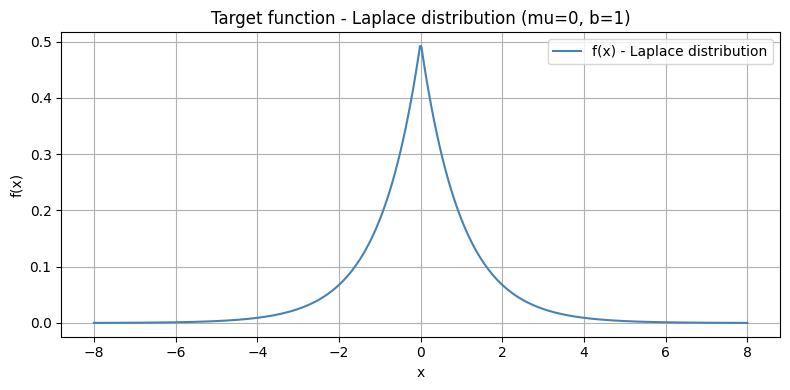

In [2]:
def laplace(x: np.ndarray, mu: float = 0.0, b: float = 1.0) -> np.ndarray:
    """Laplace distribution probability density function."""
    return (1.0 / (2.0 * b)) * np.exp(-np.abs(x - mu) / b)


# Data generation
N_SAMPLES   = 500
X_MIN, X_MAX = -8.0, 8.0

x_data = np.linspace(X_MIN, X_MAX, N_SAMPLES)
y_data = laplace(x_data)

# Save raw data
raw_df = pd.DataFrame({"x": x_data, "f_x": y_data})
raw_df.to_csv("../../data/assignment_05/raw/laplace_raw.csv", index=False)

# Quick plot of the target function
plt.figure(figsize=(8, 4))
plt.plot(x_data, y_data, color="steelblue", label="f(x) - Laplace distribution")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Target function - Laplace distribution (mu=0, b=1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Experiment helper

To ensure reliable results, every configuration is evaluated over **25 independent runs** with different random weight initializations.  
For each run MSE and MAE are computed. Aggregated statistics (min, mean, std, max) are reported.

In [3]:
N_RUNS = 25  # number of independent runs per configuration


def run_experiment(
    x: np.ndarray,
    y: np.ndarray,
    n_hidden: int,
    learning_rate: float,
    n_iterations: int,
    n_runs: int = N_RUNS,
) -> dict:
    """
    Train MLP n_runs times with random initialization and collect MSE and MAE.

    Returns a dict with lists of per-run results and the best model.
    """
    mse_results = []
    mae_results = []
    best_mse    = np.inf
    best_model  = None

    for run in range(n_runs):
        model = MLP(n_hidden=n_hidden, learning_rate=learning_rate)
        model.train(x, y, n_iterations=n_iterations)
        y_pred = model.predict(x)

        mse = mean_squared_error(y, y_pred)
        mae = mean_absolute_error(y, y_pred)

        mse_results.append(mse)
        mae_results.append(mae)

        if mse < best_mse:
            best_mse   = mse
            best_model = model

    return {
        "mse": np.array(mse_results),
        "mae": np.array(mae_results),
        "best_model": best_model,
    }


def aggregate(results: dict) -> dict:
    """Compute min, mean, std, max for MSE and MAE from experiment results."""
    out = {}
    for metric in ("mse", "mae"):
        vals = results[metric]
        out[metric] = {
            "min":  float(np.min(vals)),
            "mean": float(np.mean(vals)),
            "std":  float(np.std(vals)),
            "max":  float(np.max(vals)),
        }
    return out


def build_table(param_name: str, param_values: list, stats_list: list, metric: str) -> pd.DataFrame:
    """Build a results DataFrame for a single metric."""
    rows = []
    for val, stats in zip(param_values, stats_list):
        s = stats[metric]
        rows.append({
            param_name: val,
            "min":  round(s["min"],  4),
            "mean": round(s["mean"], 4),
            "std":  round(s["std"],  4),
            "max":  round(s["max"],  4),
        })
    return pd.DataFrame(rows).set_index(param_name)


def plot_representation(x, y_true, best_model, title: str):
    """Plot true function vs network prediction for the best run."""
    y_pred = best_model.predict(x)
    plt.figure(figsize=(8, 4))
    plt.plot(x, y_true, label="True f(x)",      color="steelblue", linewidth=2)
    plt.plot(x, y_pred, label="Network output",  color="tomato",    linewidth=2, linestyle="--")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 4. Baseline

The baseline configuration is established first. All subsequent experiments change **one parameter at a time** relative to this baseline.

| Parameter       | Baseline value |
|-----------------|----------------|
| n_hidden        | 10             |
| learning_rate   | 0.01           |
| n_iterations    | 10000          |

Baseline MSE: {'min': 0.0004969421672518326, 'mean': 0.0021184278732212687, 'std': 0.0008903877617346482, 'max': 0.004050557004404716}
Baseline MAE: {'min': 0.01421669061414563, 'mean': 0.029970928212141087, 'std': 0.007164466470663913, 'max': 0.045721968277821864}


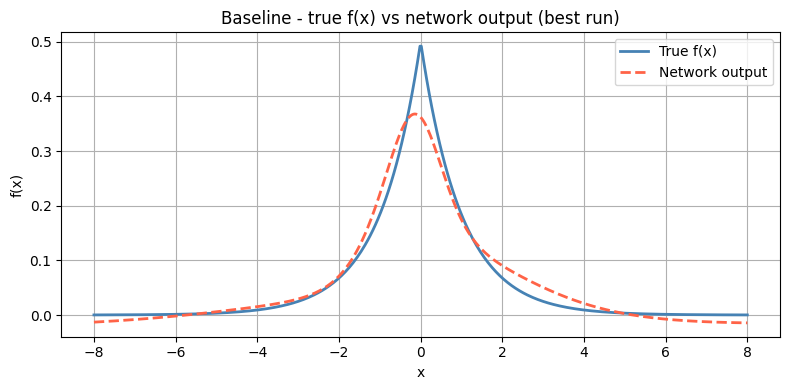

In [4]:
BASELINE = {
    "n_hidden":      10,
    "learning_rate": 0.01,
    "n_iterations":  10000,
}

baseline_results = run_experiment(
    x_data, y_data,
    n_hidden      = BASELINE["n_hidden"],
    learning_rate = BASELINE["learning_rate"],
    n_iterations  = BASELINE["n_iterations"],
)

baseline_stats = aggregate(baseline_results)
print("Baseline MSE:", baseline_stats["mse"])
print("Baseline MAE:", baseline_stats["mae"])

plot_representation(
    x_data, y_data,
    baseline_results["best_model"],
    title="Baseline - true f(x) vs network output (best run)"
)

## 5. Experiment 1 - Number of neurons in the hidden layer

All other parameters are fixed at baseline values.  
Tested values: 1, 2, 5, 10, 20, 50

In [5]:
hidden_values = [1, 2, 5, 10, 20, 50]
hidden_stats  = []
hidden_results_list = []

for n_h in hidden_values:
    res   = run_experiment(
        x_data, y_data,
        n_hidden      = n_h,
        learning_rate = BASELINE["learning_rate"],
        n_iterations  = BASELINE["n_iterations"],
    )
    hidden_results_list.append(res)
    hidden_stats.append(aggregate(res))

table_hidden_mse = build_table("n_hidden", hidden_values, hidden_stats, "mse")
table_hidden_mae = build_table("n_hidden", hidden_values, hidden_stats, "mae")

print("MSE - effect of number of hidden neurons:")
display(table_hidden_mse)

print("MAE - effect of number of hidden neurons:")
display(table_hidden_mae)

MSE - effect of number of hidden neurons:


,min,mean,std,max
n_hidden,,,,
1,0.0117,0.0117,0.0000,0.0117
2,0.0014,0.0088,0.0033,0.0118
5,0.0004,0.0037,0.0026,0.0096
10,0.0004,0.0020,0.0010,0.0043
20,0.0002,0.0013,0.0006,0.0028
50,0.0003,0.0007,0.0003,0.0014


MAE - effect of number of hidden neurons:


,min,mean,std,max
n_hidden,,,,
1,0.0768,0.0768,0.0000,0.0768
2,0.0193,0.0626,0.0176,0.0771
5,0.0118,0.0364,0.0150,0.0673
10,0.0125,0.0290,0.0079,0.0443
20,0.0083,0.0232,0.0070,0.0384
50,0.0107,0.0166,0.0051,0.0271


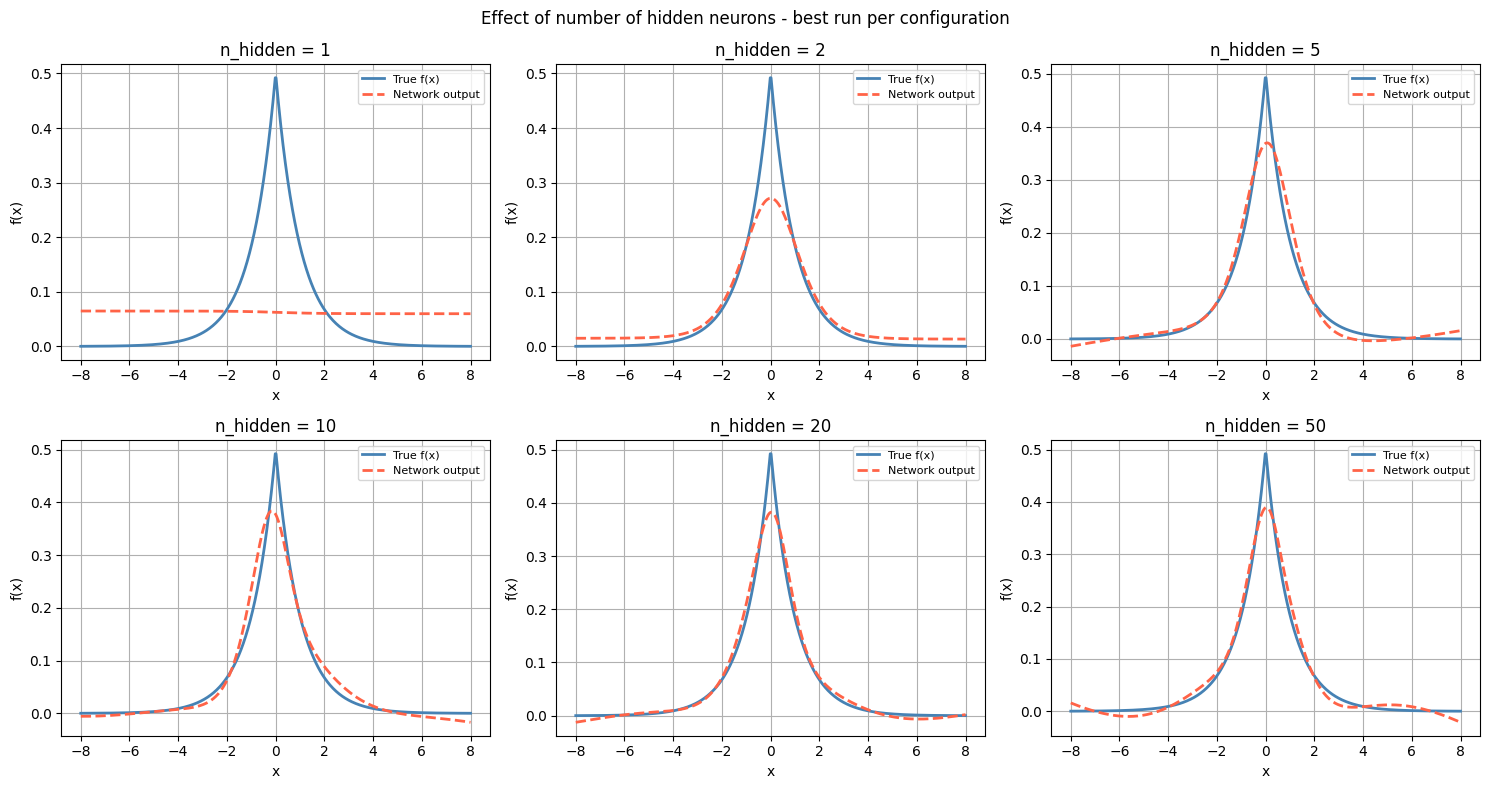

In [6]:
# Plot best run for each hidden size
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, n_h, res in zip(axes.flat, hidden_values, hidden_results_list):
    y_pred = res["best_model"].predict(x_data)
    ax.plot(x_data, y_data,  label="True f(x)",     color="steelblue", linewidth=2)
    ax.plot(x_data, y_pred,  label="Network output", color="tomato",    linewidth=2, linestyle="--")
    ax.set_title(f"n_hidden = {n_h}")
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.legend(fontsize=8)
    ax.grid(True)
plt.suptitle("Effect of number of hidden neurons - best run per configuration")
plt.tight_layout()
plt.show()

## 6. Experiment 2 - Learning rate

All other parameters are fixed at baseline values.  
Tested values: 0.001, 0.005, 0.01, 0.05, 0.1, 0.5

In [7]:
lr_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
lr_stats  = []
lr_results_list = []

for lr in lr_values:
    res = run_experiment(
        x_data, y_data,
        n_hidden      = BASELINE["n_hidden"],
        learning_rate = lr,
        n_iterations  = BASELINE["n_iterations"],
    )
    lr_results_list.append(res)
    lr_stats.append(aggregate(res))

table_lr_mse = build_table("learning_rate", lr_values, lr_stats, "mse")
table_lr_mae = build_table("learning_rate", lr_values, lr_stats, "mae")

print("MSE - effect of learning rate:")
display(table_lr_mse)

print("MAE - effect of learning rate:")
display(table_lr_mae)

MSE - effect of learning rate:


,min,mean,std,max
learning_rate,,,,
0.001,0.0037,0.0125,0.0085,0.0397
0.005,0.0008,0.0034,0.0017,0.0090
0.010,0.0005,0.0022,0.0012,0.0051
0.050,0.0002,0.0009,0.0005,0.0018
0.100,0.0002,0.0004,0.0002,0.0008
0.500,0.0000,0.0002,0.0000,0.0003


MAE - effect of learning rate:


,min,mean,std,max
learning_rate,,,,
0.001,0.0415,0.0775,0.0276,0.1481
0.005,0.0179,0.0377,0.0100,0.0657
0.010,0.0144,0.0303,0.0093,0.0528
0.050,0.0082,0.0176,0.0058,0.0283
0.100,0.0076,0.0111,0.0025,0.0175
0.500,0.0037,0.0070,0.0014,0.0097


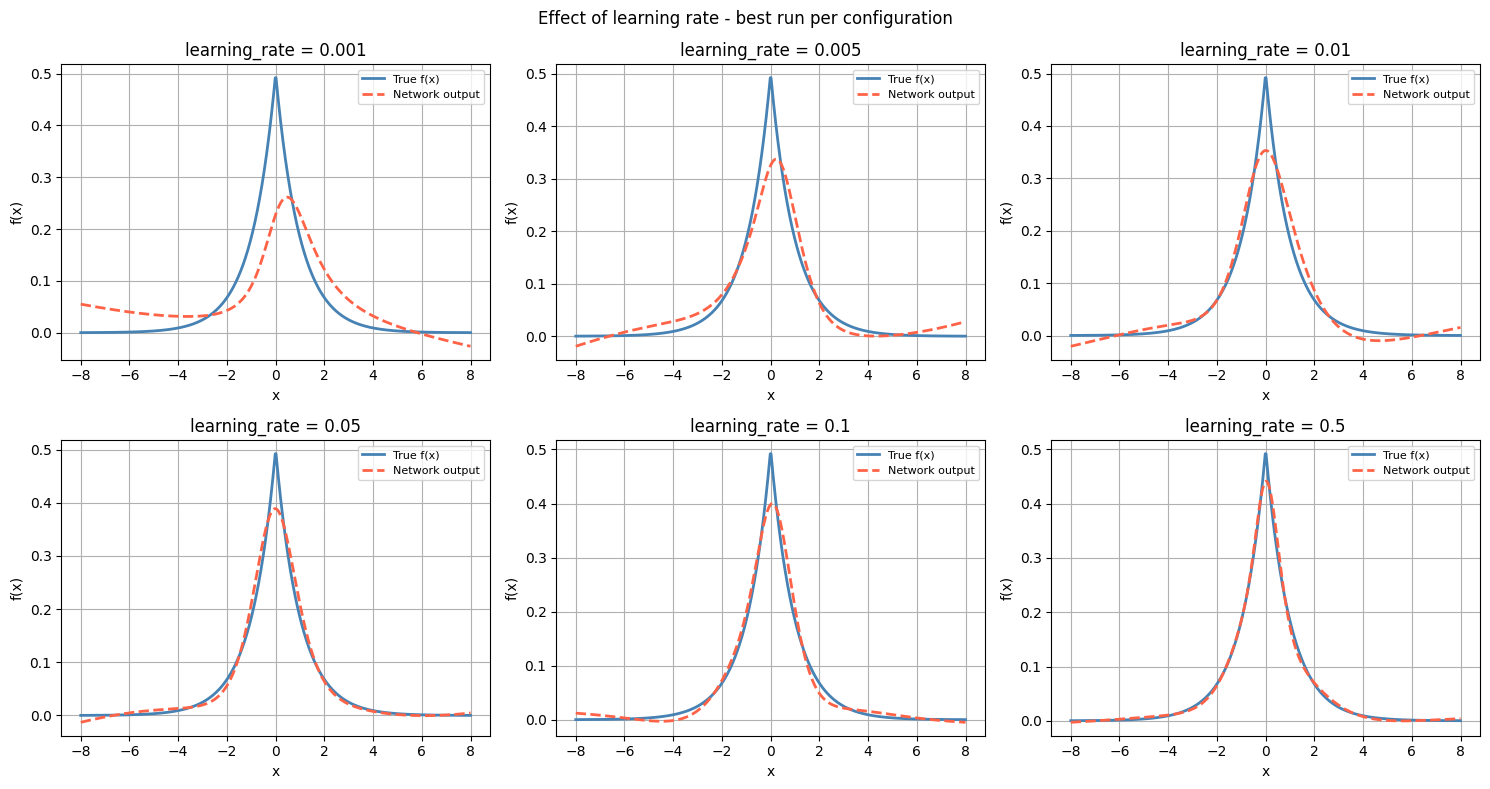

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, lr, res in zip(axes.flat, lr_values, lr_results_list):
    y_pred = res["best_model"].predict(x_data)
    ax.plot(x_data, y_data,  label="True f(x)",     color="steelblue", linewidth=2)
    ax.plot(x_data, y_pred,  label="Network output", color="tomato",    linewidth=2, linestyle="--")
    ax.set_title(f"learning_rate = {lr}")
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.legend(fontsize=8)
    ax.grid(True)
plt.suptitle("Effect of learning rate - best run per configuration")
plt.tight_layout()
plt.show()

## 7. Experiment 3 - Number of training iterations

All other parameters are fixed at baseline values.  
Tested values: 1000, 2000, 5000, 10000, 20000, 50000

In [9]:
iter_values = [1000, 2000, 5000, 10000, 20000, 50000]
iter_stats  = []
iter_results_list = []

for n_iter in iter_values:
    res = run_experiment(
        x_data, y_data,
        n_hidden      = BASELINE["n_hidden"],
        learning_rate = BASELINE["learning_rate"],
        n_iterations  = n_iter,
    )
    iter_results_list.append(res)
    iter_stats.append(aggregate(res))

table_iter_mse = build_table("n_iterations", iter_values, iter_stats, "mse")
table_iter_mae = build_table("n_iterations", iter_values, iter_stats, "mae")

print("MSE - effect of number of iterations:")
display(table_iter_mse)

print("MAE - effect of number of iterations:")
display(table_iter_mae)

MSE - effect of number of iterations:


,min,mean,std,max
n_iterations,,,,
1000,0.0024,0.0105,0.0050,0.0223
2000,0.0026,0.0061,0.0024,0.0115
5000,0.0010,0.0036,0.0020,0.0088
10000,0.0006,0.0019,0.0008,0.0036
20000,0.0003,0.0013,0.0006,0.0033
50000,0.0003,0.0007,0.0003,0.0015


MAE - effect of number of iterations:


,min,mean,std,max
n_iterations,,,,
1000,0.0279,0.0711,0.0218,0.1178
2000,0.0299,0.0513,0.0127,0.0772
5000,0.0206,0.0396,0.0112,0.0652
10000,0.0143,0.0278,0.0061,0.0436
20000,0.0094,0.0224,0.0069,0.0406
50000,0.0097,0.0153,0.0036,0.0236


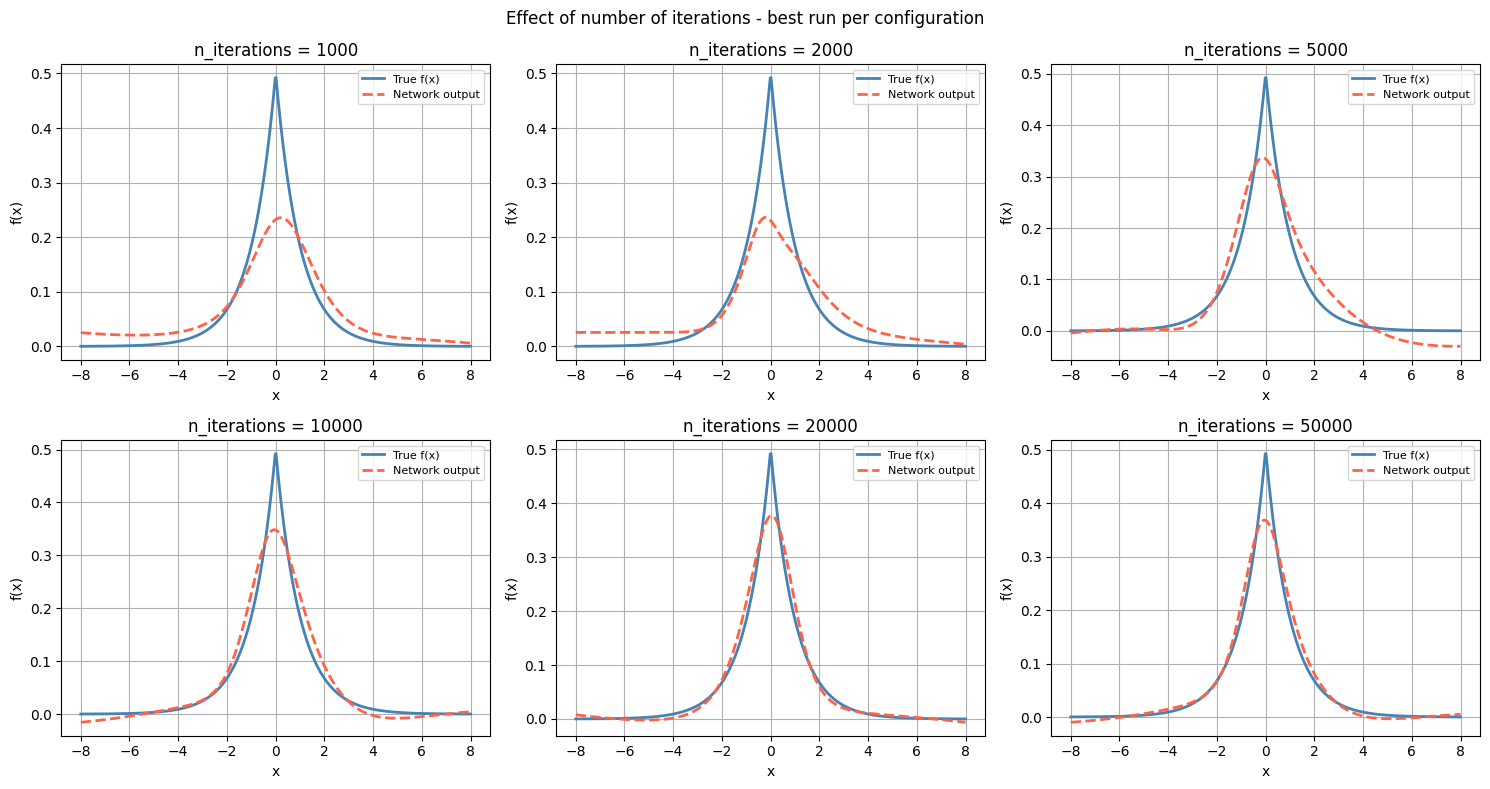

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, n_iter, res in zip(axes.flat, iter_values, iter_results_list):
    y_pred = res["best_model"].predict(x_data)
    ax.plot(x_data, y_data,  label="True f(x)",     color="steelblue", linewidth=2)
    ax.plot(x_data, y_pred,  label="Network output", color="tomato",    linewidth=2, linestyle="--")
    ax.set_title(f"n_iterations = {n_iter}")
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.legend(fontsize=8)
    ax.grid(True)
plt.suptitle("Effect of number of iterations - best run per configuration")
plt.tight_layout()
plt.show()

## 8. Save processed results

In [11]:
table_hidden_mse.to_csv("../../data/assignment_05/processed/exp1_hidden_mse.csv")
table_hidden_mae.to_csv("../../data/assignment_05/processed/exp1_hidden_mae.csv")
table_lr_mse.to_csv("../../data/assignment_05/processed/exp2_lr_mse.csv")
table_lr_mae.to_csv("../../data/assignment_05/processed/exp2_lr_mae.csv")
table_iter_mse.to_csv("../../data/assignment_05/processed/exp3_iter_mse.csv")
table_iter_mae.to_csv("../../data/assignment_05/processed/exp3_iter_mae.csv")
print("Results saved.")

Results saved.


## 9. Final conclusions

*To jest do wypełnienia*

